In [ ]:
# Run from the repo root so data/, models/, results/ and scripts/ resolve
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
if 'scripts' not in sys.path:
    sys.path.insert(0, 'scripts')

A straightforward and easily interpretable visualization technique, a Class Activation Map (CAM) 
will allow me to view and better understand what features the model is using to make its predictions. This first model is a proof of concept, and I still need to determine if my data set is large enough, and if I'm using the right model architecture.

Below is code to initialize some variables and later the images themselves. You don't need to look too closely before moving on.

In [2]:
from fastai.vision.all import *
from scipy.ndimage import zoom

path = Path('data/animals/imagenette2-160/')

lbl_dict = dict(
    n01440764='tench',
    n02102040='English springer',
    n02979186='cassette player',
    n03000684='chain saw',
    n03028079='church',
    n03394916='French horn',
    n03417042='garbage truck',
    n03425413='gas pump',
    n03445777='golf ball',
    n03888257='parachute',
    birds='bird'
)

# The mighty, immutable tuple!
birdie_paths = tuple(['/Users/ossie/sdhnet/data/CAM_imgs/birdie.jpg',
                   '/Users/ossie/sdhnet/data/CAM_imgs/birdie-2.jpg',
                   '/Users/ossie/sdhnet/data/CAM_imgs/birdie-3.jpg'])

chainsaw_paths = tuple(['/Users/ossie/sdhnet/data/CAM_imgs/chainsaw.jpg',
                     '/Users/ossie/sdhnet/data/CAM_imgs/chainsaw-2.jpg',
                     '/Users/ossie/sdhnet/data/CAM_imgs/chainsaw-3.jpg'])
                     

def label_func(fname):
  return lbl_dict[parent_label(fname)]

def get_lr(learner):
    lr_min, lr_steep = learner.lr_find(suggest_funcs=(minimum, steep))
    res = round( ( (lr_min + lr_steep)/2 ), 5)
    print('Learning rate finder result: ', res)
    return res

def get_img(img_path):
    img = PILImage.create(img_path).convert('L')
    return tfms_get_dl(img)
    
'''
Apply the same transformations as used in creating the DataLoaders
To create a DataLoader with a single, new image that the model hasn't seen
'''
def tfms_get_dl(img):
    item_tfms = Resize(128)
    batch_tfms = Normalize.from_stats(*imagenet_stats)
    img = item_tfms(img)
    img = batch_tfms(img)

    # Display the transformed image
    display(img)
    print()
    # Create a dataloader
    dl, = first(dls.test_dl([img]))
    return dl.to('mps')

'''
For information on the various types of color maps (cmap) available,
See the docs: https://matplotlib.org/stable/users/explain/colors/colormaps.html
'''
def plot_cam(x, raw_cam, ax, colormap='hot'):
    x_dec = TensorImage(dls.train.decode((x,))[0][0])
    
    # Prepare the decoded image for imshow
    x_dec = x_dec.permute(1, 2, 0).numpy()  # Convert to (height, width, channels) and to numpy array
    
    # Ensure x_dec is in the correct range (0-1)
    if x_dec.max() > 1:
        x_dec = x_dec / 255.

    # Display the decoded image
    ax.imshow(x_dec)

    # Check if raw_cam has the correct shape
    if raw_cam.ndimension() == 3 and raw_cam.shape[0] > 1:
        cam = raw_cam[0].detach().cpu().numpy()
    elif raw_cam.ndimension() == 2:
        cam = raw_cam.detach().cpu().numpy()
    else:
        print(f"Invalid shape {raw_cam.shape} for CAM data.")

    # Normalize the CAM
    cam = (cam - cam.min()) / (cam.max() - cam.min())
    
    # Resize the CAM to match the image dimensions
    cam_resized = zoom(cam, (x_dec.shape[0] / cam.shape[0], x_dec.shape[1] / cam.shape[1]), order=1)
    
    ax.imshow(cam_resized, alpha=0.4, extent=(0, x_dec.shape[1], x_dec.shape[0], 0), interpolation='bilinear', cmap=colormap)

    # Returns a tuple
    return x_dec, cam_resized

def show_imgs(x_dec, cam, ax, colormap, alpha=0.4, interpolation='bilinear'):
    ax.imshow(x_dec)
    ax.imshow(cam, alpha, interpolation, colormap)
    
'''
A class to define the forward pass hook
m = module or layer the to which the hook is attached
i = input to the layer
o = output from the layer
'''
import pprint
from IPython.display import display, Markdown
class Hook():
    def __init__(self, learner):
        self.learner = learner
        
    def hook_func(self, m: nn.Module, i: Tensor, o: Tensor):
        self.stored = o.detach().clone()
        
    def get_activations(self, x, layer, enum_labels=True):
        # Attach hook, get predictions
        hook = self.learner.model[0][layer][-1].register_forward_hook(self.hook_func)
        with torch.no_grad(): output = self.learner.model.eval()(x)

        # Print out a list of classes and predicted probabilities
        preds = F.softmax(output, dim=-1).tolist()[0]
        if enum_labels:
            predicted_labels = {dls.vocab[i]: round(prob, 3) for i, prob in enumerate(preds)}
            printed_labels = pprint.pformat(predicted_labels)
            display(Markdown(f"```python\n{printed_labels}\n```"))
            print()

        # The first tensor are the activations
        return self.stored[0]

    def create_cams(self, imgs, nrows, ncols, layer, channels=512, enum_labels=False):
        fig, ax = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))  # Adjust the size
        ax = ax.flatten()  # Ensure ax is iterable
        for axis in ax: axis.axis('off')

        results = ()
        for idx, x in enumerate(imgs):
            cam = torch.einsum('ck,kij->cij', self.learner.model[1][-1].weight[:, :channels].data, 
                               self.get_activations(x, layer, enum_labels))
            results = results + (plot_cam(x, cam, ax[idx]))  # Use idx+1 for 1-based indexing
        return results

/Users/ossie/anaconda3/envs/fastbook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First, let's create a datablock and train our model.

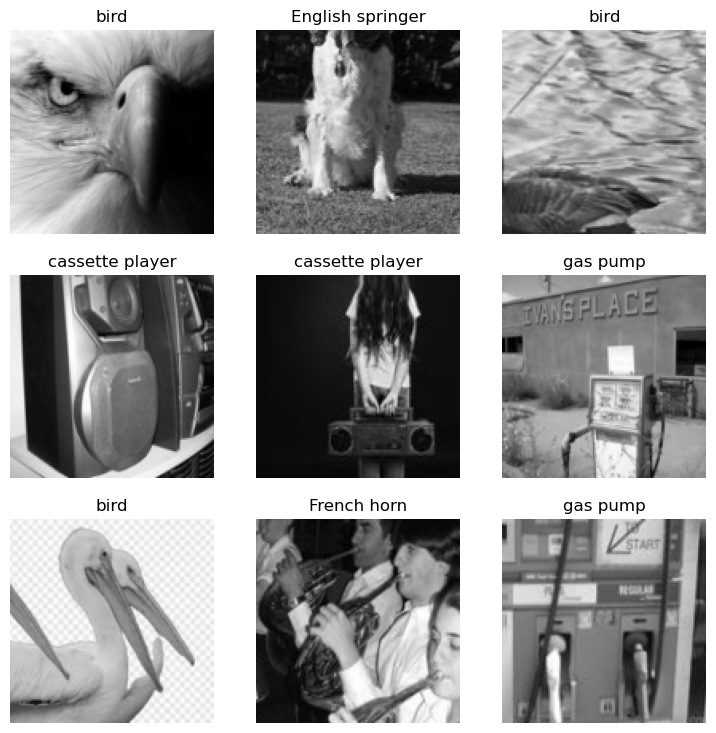

In [3]:
dblock = DataBlock(blocks = (ImageBlock(cls=PILImageBW), CategoryBlock),
                   get_items = get_image_files, get_y = label_func,
                   splitter = GrandparentSplitter(),
                   item_tfms = RandomResizedCrop(128, min_scale=0.35),
                   batch_tfms = Normalize.from_stats(*imagenet_stats))
dls = dblock.dataloaders(path, batch_size=64)
dls.show_batch()

Learning rate finder result:  0.00239


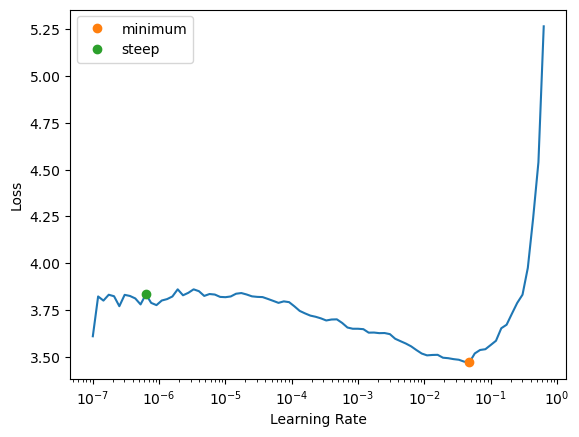

In [4]:
learner = vision_learner(dls, resnet18, metrics=[accuracy, F1Score(average='micro')], pretrained=False)
lr = get_lr(learner)

The two images used for the CAM were taken from google images, and have not been seen before by the model. Both images are relatively simple, with some but not too many potentially distracting objects in the images.

In [5]:
%%capture
birdie_imgs, chainsaw_imgs = [], []
for i in birdie_paths:
    birdie_imgs.append(get_img(i))
for i in chainsaw_paths:
    chainsaw_imgs.append(get_img(i))

In [6]:
learner.fit_one_cycle(10, lr)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.677846,2.100634,0.337867,0.337867,00:27
1,2.095041,4.400301,0.318922,0.318922,00:26
2,1.916548,3.485078,0.258441,0.258441,00:26
3,1.695611,2.020067,0.351227,0.351227,00:26
4,1.679773,1.995989,0.441584,0.441584,00:26
5,1.491490,1.770982,0.456886,0.456886,00:26
6,1.337985,1.804591,0.513481,0.513481,00:26
7,1.172421,1.079930,0.648288,0.648288,00:26
8,1.026498,0.924539,0.704639,0.704639,00:26
9,0.983469,0.907677,0.709983,0.709983,00:26


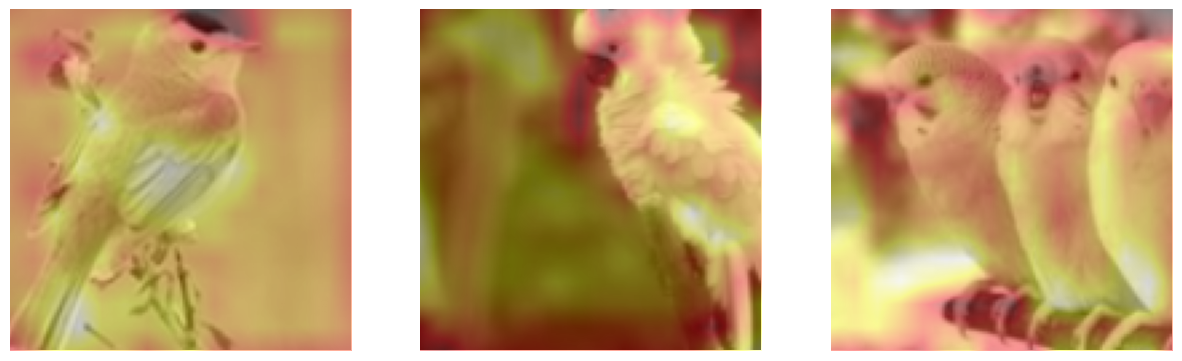

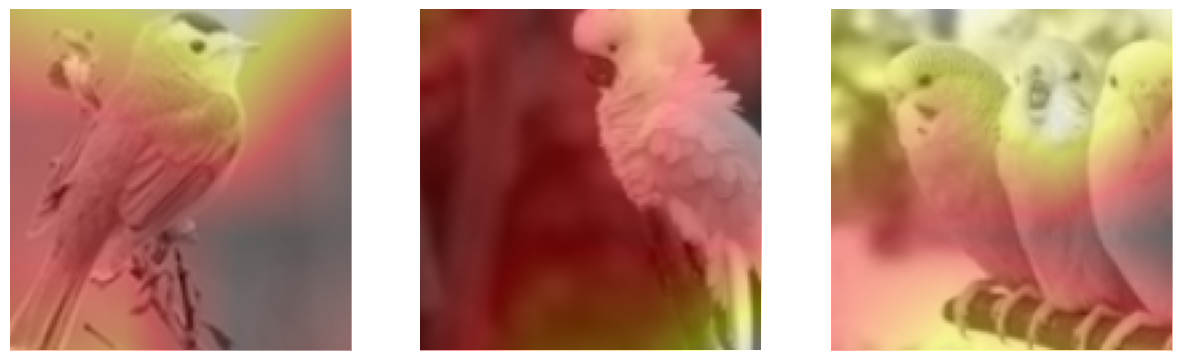

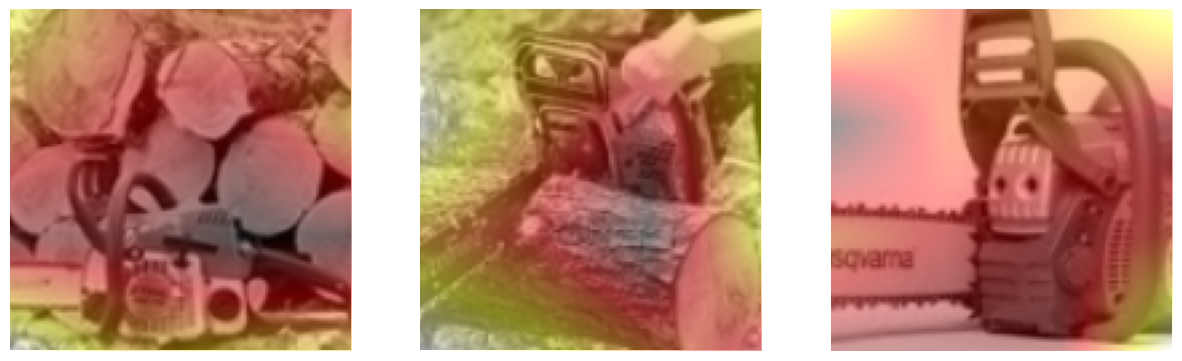

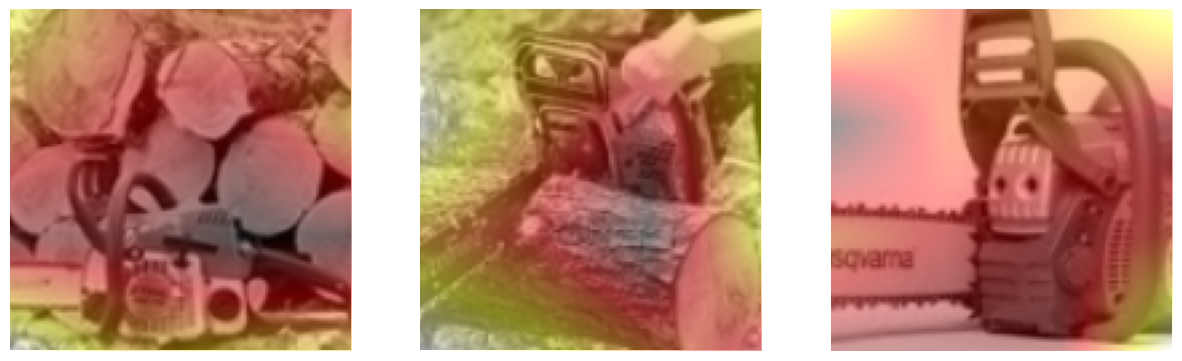

In [8]:
hook = Hook(learner) 
output = hook.create_cams(birdie_imgs, nrows=1, ncols=3, layer=5, channels=128)
output = hook.create_cams(birdie_imgs, nrows=1, ncols=3, layer=7, channels=512)

output = hook.create_cams(chainsaw_imgs, nrows=1, ncols=3, layer=5, channels=512)
output = hook.create_cams(chainsaw_imgs, nrows=1, ncols=3, layer=7, channels=512)

The read areas in the 'coolwarm' colormap identify areas that had a strong influence in classfiying the image. The blue areas represent low activation areas that may be unimportant or even sway classification away from the target category. In this example, we can see a heavy weight towards the shape and outline of the bird's feathers. Surprisingly, the head is not weighed heavily. In terms of shape, it may not be very distinct from shapes seen in other classes.

The chainsaw CAM seems to show the model relying more on the tip of the blade or even handle area of the chainsaw.